# Actividad 9 — Pipeline ETL Completo

**Proyecto:** Prediccion de Produccion de Limon en el Peru  
**Pipeline:** Fase 1 — Ingenieria de Datos  

---

## Objetivo
Ejecutar el pipeline ETL completo: **Extraer** el dataset integrado, **Transformar** (escalado StandardScaler) y **Cargar** en PostgreSQL y en CSV. El resultado es el `master_dataset_fase1.csv` listo para el modelo LSTM-Attention.

## Las 3 fases del ETL
| Fase | Descripcion | Salida |
|------|-------------|--------|
| **E** — Extraccion | Leer `dataset_integrado.csv`, validar calidad | Dataset en memoria |
| **T** — Transformacion | StandardScaler en variables numericas | Dataset escalado + scaler.pkl |
| **L** — Carga | Insertar en PostgreSQL + exportar CSV | Star Schema + master_dataset_fase1.csv |

## Regla de esta actividad
> No se calculan lags, month_sin/cos ni sentimiento NLP. Eso es Fase 2.


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
OUTPUT = CONFIG['output']

# Credenciales PostgreSQL
PG_USER = 'postgres'
PG_PASS = 'postgres'
PG_HOST = 'localhost'
PG_PORT = '5432'
PG_DB   = 'limon_analytics_db'

os.makedirs(OUTPUT['etl'], exist_ok=True)
os.makedirs('models/scalers', exist_ok=True)
print('Config cargado OK | Raiz:', os.getcwd())
print('Carpeta ETL:', OUTPUT['etl'])


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-
Carpeta ETL: pipeline/output/09_etl/


---
# E — Extraccion


In [2]:
# Leer el dataset integrado de la Actividad 6
df = pd.read_csv(OUTPUT['integracion'] + 'dataset_integrado.csv')
print(f'Dataset integrado cargado: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
print()

# Validacion de calidad
nulos = df.isnull().sum().sum()
dupes = df.duplicated(subset=['fecha_evento','departamento','provincia']).sum()
print(f'Nulos totales: {nulos}')
print(f'Duplicados en llave maestra: {dupes}')
print(f'Rango temporal: {df["fecha_evento"].min()} -> {df["fecha_evento"].max()}')
print(f'Departamentos: {df["departamento"].nunique()}')
print(f'Provincias: {df["provincia"].nunique()}')
print(f'Meses: {df["fecha_evento"].nunique()}')
print()

if nulos == 0 and dupes == 0:
    print('OK: Dataset listo para el ETL.')
else:
    print('ADVERTENCIA: Hay nulos o duplicados. Revisar Actividad 6.')

# Estadisticas descriptivas
cols_num = [c for c in df.columns if df[c].dtype in ['float64','int64']
            and c not in ['fecha_evento','departamento','provincia']]
print()
print('Estadisticas descriptivas (valores originales):')
display(df[cols_num].describe().round(3))


Dataset integrado cargado: (5880, 17)
Columnas: ['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M', 'n_noticias']

Nulos totales: 0
Duplicados en llave maestra: 0
Rango temporal: 2021-01 -> 2025-08
Departamentos: 23
Provincias: 105
Meses: 56

OK: Dataset listo para el ETL.

Estadisticas descriptivas (valores originales):


,produccion_t,cosecha_ha,precio_chacra_kg,num_emergencias,total_afectados,ALLSKY_SFC_SW_DWN,PRECTOTCORR,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,WS2M,n_noticias
count,5880.000,5880.0,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000
mean,17.082,0.0,1.498,1.055,30.688,17.787,55.441,11.579,72.094,18.496,27.082,11.845,1.617,8.929
std,28.504,0.0,0.588,3.509,317.719,2.959,74.064,3.511,11.540,6.400,5.842,7.498,1.139,5.487
min,0.000,0.0,0.250,0.000,0.000,9.220,0.000,1.840,22.690,3.420,13.390,-5.930,0.010,0.000
25%,0.000,0.0,1.000,0.000,0.000,15.680,7.485,9.170,66.060,13.408,22.660,5.848,0.250,5.000
50%,5.540,0.0,1.400,0.000,0.000,17.490,29.760,11.525,72.250,18.765,27.130,12.595,1.700,8.000
75%,22.000,0.0,2.000,0.000,0.000,19.250,70.370,13.712,79.592,23.952,30.952,17.900,2.310,13.000
max,228.800,0.0,2.650,52.000,12379.000,30.860,667.430,20.370,93.920,33.660,42.400,25.510,5.360,26.000


### Interpretacion

**Que muestra:** El estado del dataset integrado antes de la transformacion. Debe tener 0 nulos y 0 duplicados para garantizar la calidad del ETL.

**Implicacion para el pipeline:** Si hay nulos o duplicados, el ETL fallara o producira resultados incorrectos. Se debe volver a la Actividad 6 para corregirlos.

**Implicacion para el modelo:** El dataset de entrada al LSTM-Attention debe ser completamente limpio. Cualquier nulo en las variables de entrada causaria errores durante el entrenamiento.


---
# T — Transformacion: StandardScaler

Se aplica StandardScaler a las variables numericas para normalizar las escalas. Esto es necesario porque las variables tienen unidades muy diferentes (toneladas, S/./kg, °C, mm, etc.).


In [3]:
# Identificar columnas a escalar
# Excluir: llaves (fecha, dpto, prov) y variables de Fase 2 (month_sin/cos, sentiment)
COLS_NO_ESCALAR = ['fecha_evento','departamento','provincia']
COLS_FASE2 = ['month_sin','month_cos','sentiment_score','nlp_sentiment']

cols_escalar = [
    c for c in df.columns
    if c not in COLS_NO_ESCALAR + COLS_FASE2
    and df[c].dtype in ['float64','int64']
]

print('Variables a escalar:')
for c in cols_escalar:
    print(f'  {c:<30} min={df[c].min():.2f}  max={df[c].max():.2f}  mean={df[c].mean():.2f}')
print(f'\nTotal: {len(cols_escalar)} variables')


Variables a escalar:
  produccion_t                   min=0.00  max=228.80  mean=17.08
  cosecha_ha                     min=0.00  max=0.00  mean=0.00
  precio_chacra_kg               min=0.25  max=2.65  mean=1.50
  num_emergencias                min=0.00  max=52.00  mean=1.05
  total_afectados                min=0.00  max=12379.00  mean=30.69
  ALLSKY_SFC_SW_DWN              min=9.22  max=30.86  mean=17.79
  PRECTOTCORR                    min=0.00  max=667.43  mean=55.44
  QV2M                           min=1.84  max=20.37  mean=11.58
  RH2M                           min=22.69  max=93.92  mean=72.09
  T2M                            min=3.42  max=33.66  mean=18.50
  T2M_MAX                        min=13.39  max=42.40  mean=27.08
  T2M_MIN                        min=-5.93  max=25.51  mean=11.85
  WS2M                           min=0.01  max=5.36  mean=1.62
  n_noticias                     min=0.00  max=26.00  mean=8.93

Total: 14 variables


## Grafico 1 — Distribuciones antes vs despues del escalado


Scaler guardado: models/scalers/scaler_fase1.pkl
Variables escaladas: 14



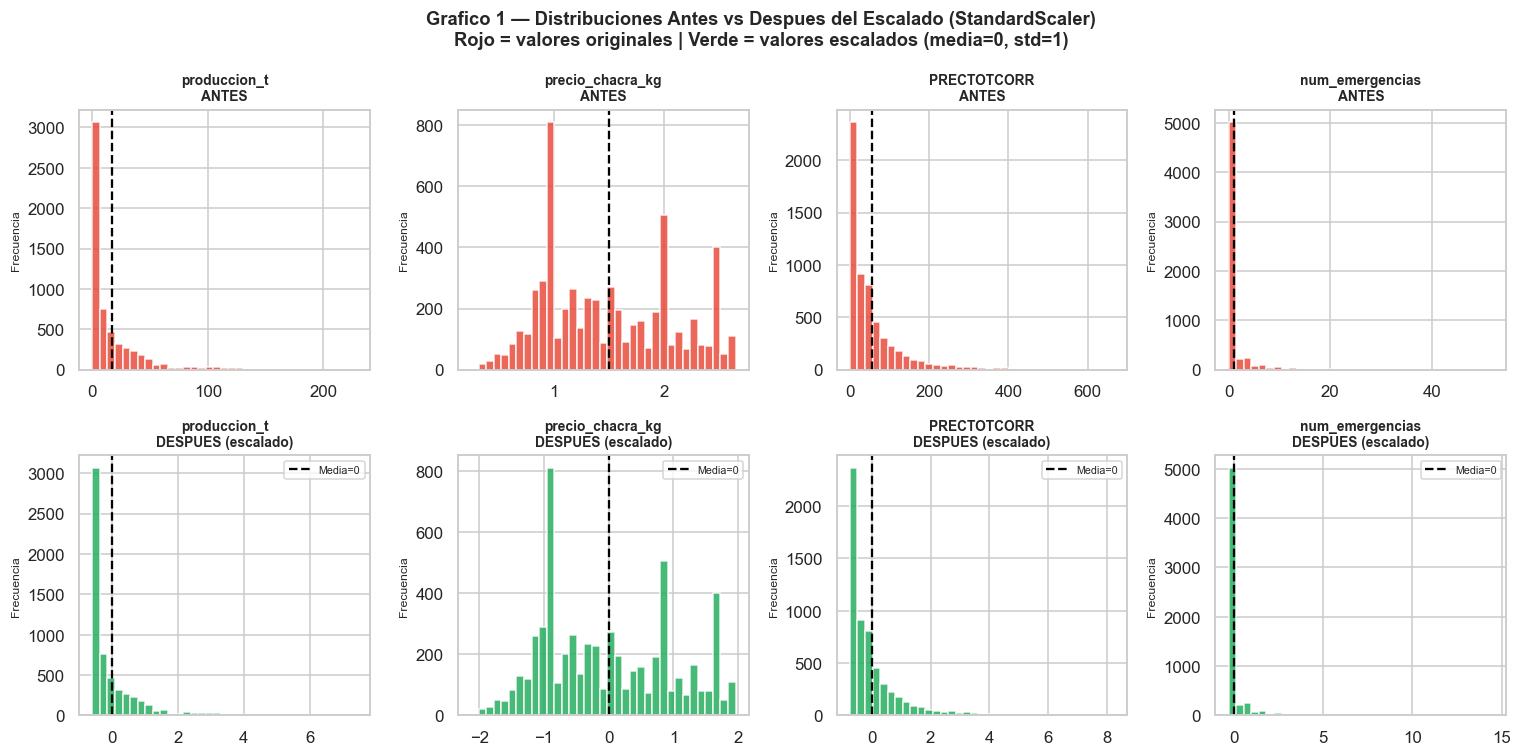

Guardado: pipeline/output/03_eda/act09_g1_escalado.png


In [4]:
# Guardar valores originales antes de escalar
df_raw = df.copy()

# Aplicar StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_escalar] = scaler.fit_transform(df[cols_escalar])

# Guardar el scaler
scaler_path = 'models/scalers/scaler_fase1.pkl'
joblib.dump(scaler, scaler_path)
print(f'Scaler guardado: {scaler_path}')
print(f'Variables escaladas: {len(cols_escalar)}')
print()

# Grafico: antes vs despues para 4 variables clave
vars_plot = ['produccion_t','precio_chacra_kg']
vars_nasa = [c for c in cols_escalar if c in ['T2M','t2m','PRECTOTCORR','prectotcorr']][:1]
vars_indeci = [c for c in cols_escalar if 'emergencia' in c.lower()][:1]
vars_plot = (vars_plot + vars_nasa + vars_indeci)[:4]
vars_plot = [c for c in vars_plot if c in df.columns]

fig, axes = plt.subplots(2, len(vars_plot), figsize=(14, 7))
if len(vars_plot) == 1: axes = axes.reshape(2,1)

for j, var in enumerate(vars_plot):
    # Antes
    axes[0][j].hist(df_raw[var].dropna(), bins=35, color='#e74c3c',
                    edgecolor='white', alpha=0.85)
    axes[0][j].set_title(f'{var}\nANTES', fontsize=9, fontweight='bold')
    axes[0][j].set_ylabel('Frecuencia', fontsize=8)
    axes[0][j].axvline(df_raw[var].mean(), color='black', linestyle='--', linewidth=1.5)

    # Despues
    axes[1][j].hist(df_scaled[var].dropna(), bins=35, color='#27ae60',
                    edgecolor='white', alpha=0.85)
    axes[1][j].set_title(f'{var}\nDESPUES (escalado)', fontsize=9, fontweight='bold')
    axes[1][j].set_ylabel('Frecuencia', fontsize=8)
    axes[1][j].axvline(0, color='black', linestyle='--', linewidth=1.5,
                       label='Media=0')
    axes[1][j].legend(fontsize=7)

plt.suptitle('Grafico 1 — Distribuciones Antes vs Despues del Escalado (StandardScaler)\n'
             'Rojo = valores originales | Verde = valores escalados (media=0, std=1)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g1 = OUTPUT['eda'] + 'act09_g1_escalado.png'
plt.savefig(g1, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g1)


### Interpretacion

**Que muestra:** La distribucion de las variables antes (rojo) y despues (verde) del escalado. Despues del escalado, todas las variables tienen media=0 y std=1.

**Por que StandardScaler:** Las variables tienen escalas muy diferentes (produccion en toneladas, precio en S/./kg, temperatura en °C). Sin escalado, el LSTM-Attention daria mas peso a las variables con valores grandes, ignorando las de valores pequenos.

**Implicacion para el modelo:** El scaler guardado en `scaler_fase1.pkl` se usara en la Fase 2 para invertir la transformacion y obtener predicciones en las unidades originales (toneladas de limon).


---
# L — Carga en PostgreSQL

Insertar los datos en el Star Schema siguiendo el orden correcto: dimensiones primero, tabla de hechos al final.


In [5]:
import psycopg2
from psycopg2.extras import execute_values

PG_DISPONIBLE = False
try:
    conn_test = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database=PG_DB, connect_timeout=5
    )
    conn_test.close()
    PG_DISPONIBLE = True
    print('OK: PostgreSQL disponible.')
except Exception as e:
    print(f'PostgreSQL no disponible: {e}')
    print('Se exportara solo el CSV. El Star Schema se cargara cuando PostgreSQL este disponible.')


OK: PostgreSQL disponible.


In [6]:
if PG_DISPONIBLE:
    conn = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database=PG_DB
    )
    cursor = conn.cursor()

    # Limpiar tablas antes de insertar (para re-ejecucion limpia)
    print('Limpiando tablas para insercion limpia...')
    cursor.execute('TRUNCATE TABLE fact_produccion_limon CASCADE')
    cursor.execute('TRUNCATE TABLE dim_clima CASCADE')
    cursor.execute('TRUNCATE TABLE dim_emergencia CASCADE')
    cursor.execute('TRUNCATE TABLE dim_noticias CASCADE')
    cursor.execute('TRUNCATE TABLE dim_tiempo CASCADE')
    cursor.execute('TRUNCATE TABLE dim_ubicacion CASCADE')
    conn.commit()
    print('  OK: Tablas limpiadas.')
    print()

    # ── 1. dim_tiempo ─────────────────────────────────────────────────────
    print('[1/6] Insertando dim_tiempo...')
    fechas_unicas = df_scaled[['fecha_evento']].drop_duplicates().copy()
    fechas_unicas['anho'] = fechas_unicas['fecha_evento'].str[:4].astype(int)
    fechas_unicas['mes']  = fechas_unicas['fecha_evento'].str[5:7].astype(int)
    meses_nombres = {1:'Enero',2:'Febrero',3:'Marzo',4:'Abril',5:'Mayo',6:'Junio',
                     7:'Julio',8:'Agosto',9:'Septiembre',10:'Octubre',11:'Noviembre',12:'Diciembre'}
    fechas_unicas['nombre_mes'] = fechas_unicas['mes'].map(meses_nombres)

    rows_tiempo = [
        (row['fecha_evento'], row['anho'], row['mes'], row['nombre_mes'])
        for _, row in fechas_unicas.iterrows()
    ]
    execute_values(cursor,
        'INSERT INTO dim_tiempo (fecha_evento, anho, mes, nombre_mes) VALUES %s',
        rows_tiempo
    )
    conn.commit()
    print(f'  Insertados: {len(rows_tiempo)} registros')

    # ── 2. dim_ubicacion ──────────────────────────────────────────────────
    print('[2/6] Insertando dim_ubicacion...')
    ubic_unicas = df_scaled[['departamento','provincia']].drop_duplicates()
    rows_ubic = [(row['departamento'], row['provincia'])
                 for _, row in ubic_unicas.iterrows()]
    execute_values(cursor,
        'INSERT INTO dim_ubicacion (departamento, provincia) VALUES %s',
        rows_ubic
    )
    conn.commit()
    print(f'  Insertados: {len(rows_ubic)} registros')

    # ── 3. dim_clima ──────────────────────────────────────────────────────
    print('[3/6] Insertando dim_clima...')
    vars_clima_db = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','QV2M','ALLSKY_SFC_SW_DWN','WS2M']
    vars_clima_disponibles = [c for c in vars_clima_db if c in df_scaled.columns]
    if not vars_clima_disponibles:
        vars_clima_disponibles = [c for c in vars_clima_db if c.lower() in df_scaled.columns]
        vars_clima_disponibles = [c.lower() for c in vars_clima_db if c.lower() in df_scaled.columns]

    if vars_clima_disponibles:
        rows_clima = [tuple(row[c] if not pd.isna(row[c]) else None
                           for c in vars_clima_disponibles)
                      for _, row in df_scaled.iterrows()]
        cols_clima_sql = ', '.join(c.lower() for c in vars_clima_disponibles)
        execute_values(cursor,
            f'INSERT INTO dim_clima ({cols_clima_sql}) VALUES %s',
            rows_clima
        )
        conn.commit()
        print(f'  Insertados: {len(rows_clima)} registros')
    else:
        print('  Sin variables climaticas disponibles.')

    # ── 4. dim_emergencia ─────────────────────────────────────────────────
    print('[4/6] Insertando dim_emergencia...')
    col_emer = 'num_emergencias' if 'num_emergencias' in df_scaled.columns else None
    col_afec = 'total_afectados' if 'total_afectados' in df_scaled.columns else None
    col_hect = 'has_cultivo_perdidas' if 'has_cultivo_perdidas' in df_scaled.columns else None

    rows_emer = []
    for _, row in df_scaled.iterrows():
        n_emer = int(row[col_emer]) if col_emer and not pd.isna(row[col_emer]) else 0
        t_afec = int(row[col_afec]) if col_afec and not pd.isna(row[col_afec]) else 0
        h_perd = float(row[col_hect]) if col_hect and not pd.isna(row[col_hect]) else 0.0
        rows_emer.append((n_emer, t_afec, h_perd))
    execute_values(cursor,
        'INSERT INTO dim_emergencia (num_emergencias, total_afectados, has_cultivo_perdidas) VALUES %s',
        rows_emer
    )
    conn.commit()
    print(f'  Insertados: {len(rows_emer)} registros')

    # ── 5. dim_noticias ───────────────────────────────────────────────────
    print('[5/6] Insertando dim_noticias...')
    col_not = 'n_noticias' if 'n_noticias' in df_scaled.columns else None
    rows_not = []
    for _, row in df_scaled.iterrows():
        n_not = int(row[col_not]) if col_not and not pd.isna(row[col_not]) else 0
        rows_not.append((n_not, None))  # avg_sentimiento = NULL en Fase 1
    execute_values(cursor,
        'INSERT INTO dim_noticias (n_noticias, avg_sentimiento) VALUES %s',
        rows_not
    )
    conn.commit()
    print(f'  Insertados: {len(rows_not)} registros')

    # ── 6. fact_produccion_limon ──────────────────────────────────────────
    print('[6/6] Insertando fact_produccion_limon...')

    # Obtener IDs de dimensiones
    cursor.execute('SELECT id_tiempo, fecha_evento FROM dim_tiempo')
    map_tiempo = {row[1]: row[0] for row in cursor.fetchall()}

    cursor.execute('SELECT id_ubicacion, departamento, provincia FROM dim_ubicacion')
    map_ubic = {(row[1], row[2]): row[0] for row in cursor.fetchall()}

    cursor.execute('SELECT id_clima FROM dim_clima ORDER BY id_clima')
    ids_clima = [row[0] for row in cursor.fetchall()]

    cursor.execute('SELECT id_emergencia FROM dim_emergencia ORDER BY id_emergencia')
    ids_emer = [row[0] for row in cursor.fetchall()]

    cursor.execute('SELECT id_noticias FROM dim_noticias ORDER BY id_noticias')
    ids_not = [row[0] for row in cursor.fetchall()]

    col_prod = 'produccion_t' if 'produccion_t' in df_scaled.columns else None
    col_cos  = 'cosecha_ha'   if 'cosecha_ha'   in df_scaled.columns else None
    col_prec = 'precio_chacra_kg' if 'precio_chacra_kg' in df_scaled.columns else None

    rows_fact = []
    for i, (_, row) in enumerate(df_scaled.iterrows()):
        id_t = map_tiempo.get(row['fecha_evento'])
        id_u = map_ubic.get((row['departamento'], row['provincia']))
        id_c = ids_clima[i] if i < len(ids_clima) else None
        id_e = ids_emer[i]  if i < len(ids_emer)  else None
        id_n = ids_not[i]   if i < len(ids_not)   else None

        prod = float(row[col_prod]) if col_prod and not pd.isna(row[col_prod]) else 0.0
        cos  = float(row[col_cos])  if col_cos  and not pd.isna(row[col_cos])  else 0.0
        prec = float(row[col_prec]) if col_prec and not pd.isna(row[col_prec]) else None

        if id_t and id_u:
            rows_fact.append((id_t, id_u, id_c, id_e, id_n, prod, cos, prec))

    execute_values(cursor,
        'INSERT INTO fact_produccion_limon '
        '(id_tiempo, id_ubicacion, id_clima, id_emergencia, id_noticias, '
        ' produccion_t, cosecha_ha, precio_chacra_kg) VALUES %s',
        rows_fact
    )
    conn.commit()
    print(f'  Insertados: {len(rows_fact)} registros')

    cursor.close()
    conn.close()
    print()
    print('OK: Carga en PostgreSQL completada.')
else:
    print('PostgreSQL no disponible. Saltando carga en base de datos.')


Limpiando tablas para insercion limpia...


  OK: Tablas limpiadas.

[1/6] Insertando dim_tiempo...
  Insertados: 56 registros
[2/6] Insertando dim_ubicacion...
  Insertados: 105 registros
[3/6] Insertando dim_clima...


  Insertados: 5880 registros
[4/6] Insertando dim_emergencia...
  Insertados: 5880 registros
[5/6] Insertando dim_noticias...


  Insertados: 5880 registros
[6/6] Insertando fact_produccion_limon...


  Insertados: 5880 registros

OK: Carga en PostgreSQL completada.


### Interpretacion

**Que muestra:** El proceso de insercion de datos en el Star Schema. El orden es critico: dimensiones primero, tabla de hechos al final para respetar las restricciones de clave foranea.

**Implicacion para el pipeline:** Con los datos cargados en PostgreSQL, es posible hacer consultas SQL analiticas eficientes sobre la produccion de limon por departamento, periodo, condicion climatica, etc.

**Implicacion para el modelo:** El Star Schema permite extraer subconjuntos del dataset para entrenamiento y validacion del LSTM-Attention sin necesidad de cargar todo el CSV en memoria.


## Grafico 2 — Registros insertados por tabla en PostgreSQL


Registros en cada tabla:
  dim_tiempo                          56
  dim_ubicacion                       105
  dim_clima                           5,880
  dim_emergencia                      5,880
  dim_noticias                        5,880
  fact_produccion_limon               5,880


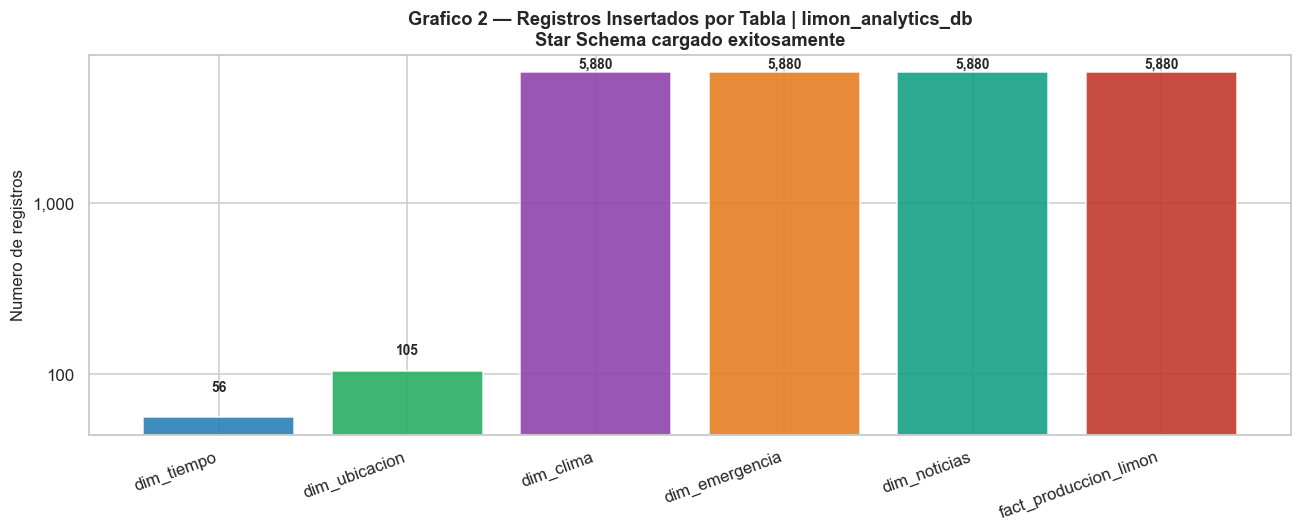

Guardado: pipeline/output/03_eda/act09_g2_conteo_tablas.png


In [7]:
if PG_DISPONIBLE:
    conn = psycopg2.connect(
        host=PG_HOST, port=PG_PORT,
        user=PG_USER, password=PG_PASS,
        database=PG_DB
    )
    cursor = conn.cursor()

    tablas = ['dim_tiempo','dim_ubicacion','dim_clima',
              'dim_emergencia','dim_noticias','fact_produccion_limon']
    conteos = {}
    for tabla in tablas:
        cursor.execute(f'SELECT COUNT(*) FROM {tabla}')
        conteos[tabla] = cursor.fetchone()[0]

    cursor.close()
    conn.close()

    print('Registros en cada tabla:')
    for tabla, n in conteos.items():
        print(f'  {tabla:<35} {n:,}')

    colores = ['#2980b9','#27ae60','#8e44ad','#e67e22','#16a085','#c0392b']
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(list(conteos.keys()), list(conteos.values()),
                  color=colores, edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, conteos.values()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylabel('Numero de registros', fontsize=11)
    ax.set_xticklabels(list(conteos.keys()), rotation=20, ha='right')
    ax.set_title('Grafico 2 — Registros Insertados por Tabla | limon_analytics_db\n'
                 'Star Schema cargado exitosamente',
                 fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    g2 = OUTPUT['eda'] + 'act09_g2_conteo_tablas.png'
    plt.savefig(g2, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g2)
else:
    print('PostgreSQL no disponible.')


### Interpretacion

**Que muestra:** El numero de registros en cada tabla del Star Schema despues de la carga. La tabla de hechos debe tener el mismo numero de filas que el dataset integrado.

**Validacion:** Si la tabla de hechos tiene menos filas que el dataset integrado, indica que algunos registros no pudieron insertarse (FK no encontrada). Si tiene mas, hay duplicados.

**Implicacion para el modelo:** Con el Star Schema cargado, se pueden hacer consultas SQL para extraer datos de entrenamiento filtrados por departamento, periodo o condicion climatica.


---
# Exportacion del Dataset Maestro


In [8]:
# Exportar dataset escalado (para el modelo LSTM)
out_scaled = OUTPUT['etl'] + 'master_dataset_fase1.csv'
df_scaled.to_csv(out_scaled, index=False, encoding='utf-8-sig')
print(f'Exportado (escalado): {out_scaled}')
print(f'  Shape: {df_scaled.shape}')

# Exportar dataset con valores originales (para graficos y validacion)
out_raw = OUTPUT['etl'] + 'master_dataset_raw_values.csv'
df_raw.to_csv(out_raw, index=False, encoding='utf-8-sig')
print(f'Exportado (original): {out_raw}')
print(f'  Shape: {df_raw.shape}')

print()
print('Columnas del dataset maestro:')
for i, col in enumerate(df_scaled.columns):
    dtype = str(df_scaled[col].dtype)
    print(f'  [{i:02d}] {col:<30} {dtype}')


Exportado (escalado): pipeline/output/09_etl/master_dataset_fase1.csv
  Shape: (5880, 17)
Exportado (original): pipeline/output/09_etl/master_dataset_raw_values.csv
  Shape: (5880, 17)

Columnas del dataset maestro:
  [00] fecha_evento                   str
  [01] departamento                   str
  [02] provincia                      str
  [03] produccion_t                   float64
  [04] cosecha_ha                     float64
  [05] precio_chacra_kg               float64
  [06] num_emergencias                float64
  [07] total_afectados                float64
  [08] ALLSKY_SFC_SW_DWN              float64
  [09] PRECTOTCORR                    float64
  [10] QV2M                           float64
  [11] RH2M                           float64
  [12] T2M                            float64
  [13] T2M_MAX                        float64
  [14] T2M_MIN                        float64
  [15] WS2M                           float64
  [16] n_noticias                     float64


## Grafico 3 — Validacion: serie produccion original vs escalada


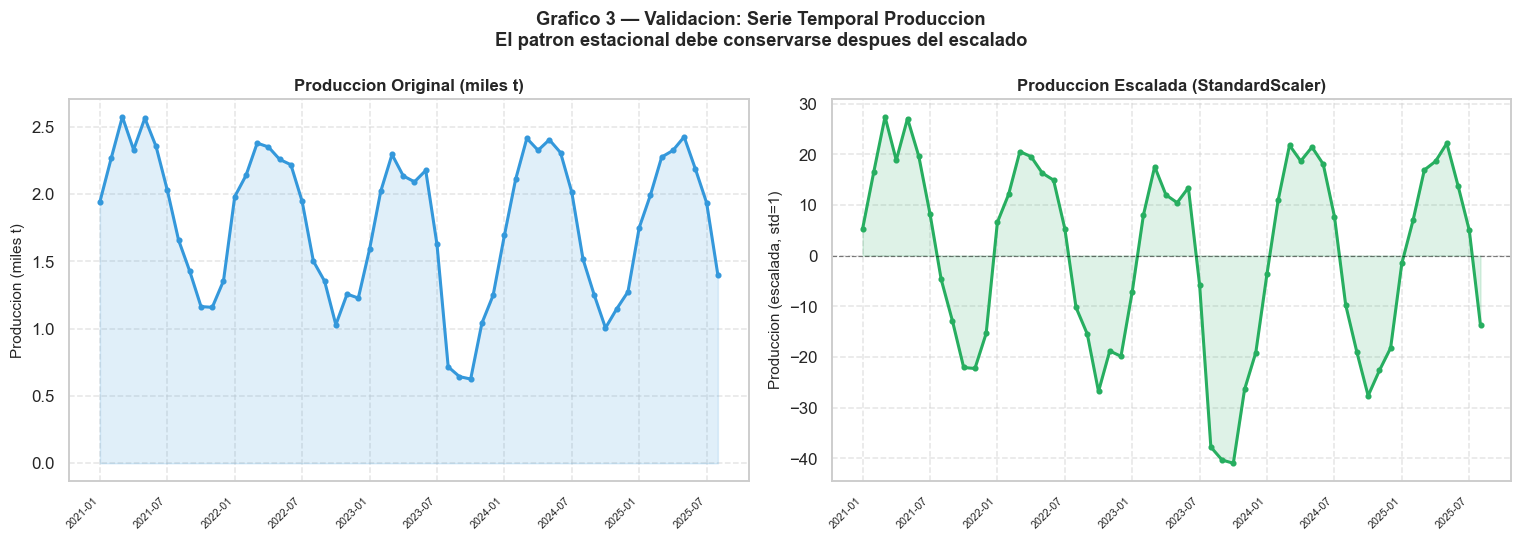

Guardado: pipeline/output/03_eda/act09_g3_validacion_serie.png


In [9]:
col_prod = 'produccion_t' if 'produccion_t' in df_scaled.columns else None

if col_prod:
    serie_raw    = df_raw.groupby('fecha_evento')[col_prod].sum().reset_index()
    serie_scaled = df_scaled.groupby('fecha_evento')[col_prod].sum().reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Serie original
    axes[0].plot(range(len(serie_raw)), serie_raw[col_prod]/1e3,
                 color='#3498db', linewidth=2, marker='o', markersize=3)
    axes[0].fill_between(range(len(serie_raw)), serie_raw[col_prod]/1e3,
                          alpha=0.15, color='#3498db')
    axes[0].set_xticks(range(0, len(serie_raw), 6))
    axes[0].set_xticklabels(serie_raw['fecha_evento'].iloc[::6], rotation=45, ha='right', fontsize=7)
    axes[0].set_ylabel('Produccion (miles t)', fontsize=10)
    axes[0].set_title('Produccion Original (miles t)', fontsize=11, fontweight='bold')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # Serie escalada
    axes[1].plot(range(len(serie_scaled)), serie_scaled[col_prod],
                 color='#27ae60', linewidth=2, marker='o', markersize=3)
    axes[1].fill_between(range(len(serie_scaled)), serie_scaled[col_prod],
                          alpha=0.15, color='#27ae60')
    axes[1].set_xticks(range(0, len(serie_scaled), 6))
    axes[1].set_xticklabels(serie_scaled['fecha_evento'].iloc[::6], rotation=45, ha='right', fontsize=7)
    axes[1].set_ylabel('Produccion (escalada, std=1)', fontsize=10)
    axes[1].set_title('Produccion Escalada (StandardScaler)', fontsize=11, fontweight='bold')
    axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.suptitle('Grafico 3 — Validacion: Serie Temporal Produccion\n'
                 'El patron estacional debe conservarse despues del escalado',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    g3 = OUTPUT['eda'] + 'act09_g3_validacion_serie.png'
    plt.savefig(g3, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g3)
else:
    print('Columna produccion_t no encontrada.')


### Interpretacion

**Que muestra:** La serie temporal de produccion antes y despues del escalado. El patron estacional (picos y valles) debe ser identico en ambas series — solo cambia la escala del eje Y.

**Validacion critica:** Si los patrones son diferentes, el escalado introdujo una distorsion y debe revisarse. El StandardScaler solo cambia la escala, no el patron temporal.

**Implicacion para el modelo:** El LSTM-Attention aprendera el patron escalado. Para interpretar las predicciones en toneladas reales, se aplicara la transformacion inversa con `scaler.inverse_transform()`.


## Grafico 4 — Correlacion del dataset final


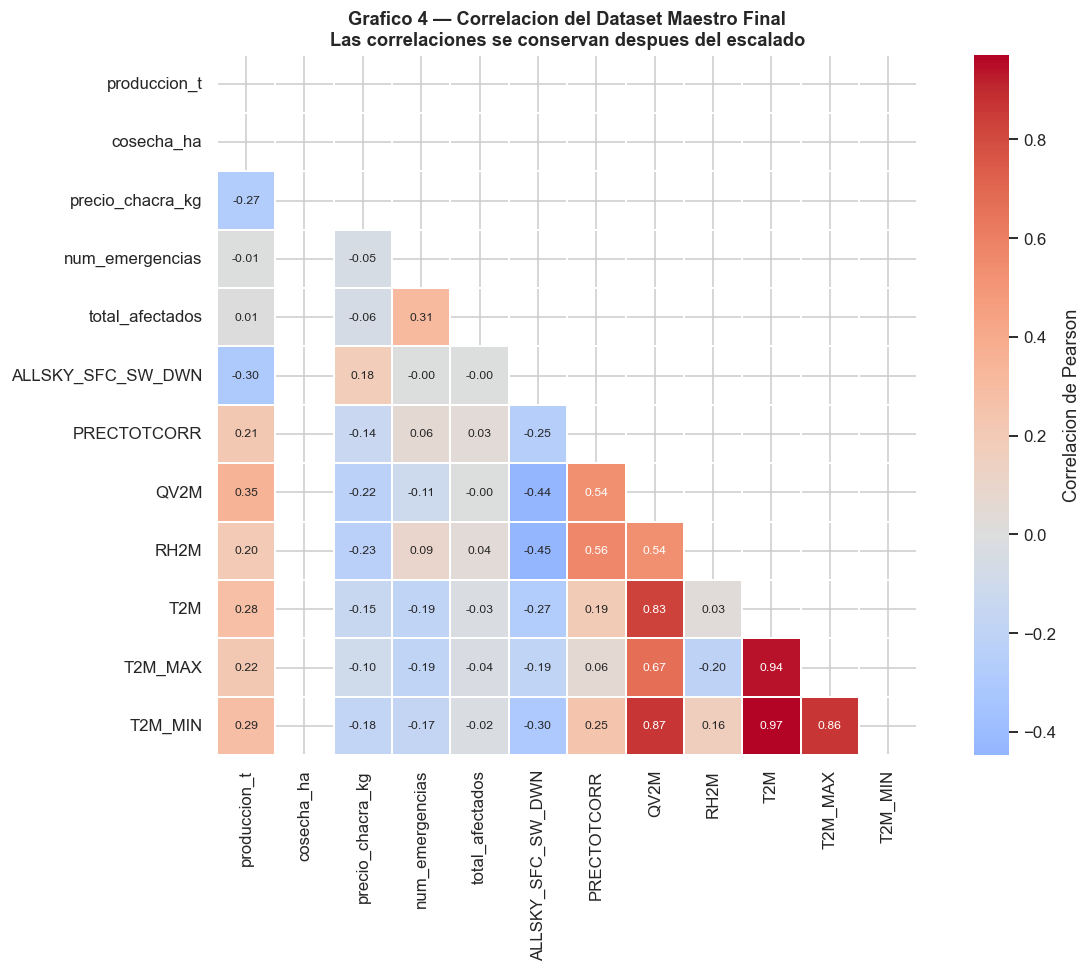

Guardado: pipeline/output/03_eda/act09_g4_correlacion_final.png

Correlaciones con produccion_t:
  QV2M                      r =   0.354  [MEDIA]
  ALLSKY_SFC_SW_DWN         r =  -0.299  [BAJA]
  T2M_MIN                   r =   0.288  [BAJA]
  T2M                       r =   0.277  [BAJA]
  precio_chacra_kg          r =  -0.273  [BAJA]
  T2M_MAX                   r =   0.217  [BAJA]
  PRECTOTCORR               r =   0.214  [BAJA]
  RH2M                      r =   0.200  [BAJA]
  num_emergencias           r =  -0.008  [BAJA]
  total_afectados           r =   0.007  [BAJA]
  cosecha_ha                r =     nan  [BAJA]


In [10]:
cols_corr = [c for c in df_scaled.columns
             if c not in ['fecha_evento','departamento','provincia']
             and df_scaled[c].dtype in ['float64','int64']][:12]

corr_final = df_scaled[cols_corr].corr().round(3)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_final, dtype=bool))
sns.heatmap(corr_final, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, ax=ax,
            cbar_kws={'label': 'Correlacion de Pearson'},
            annot_kws={'size': 8}, linewidths=0.3)
ax.set_title('Grafico 4 — Correlacion del Dataset Maestro Final\n'
             'Las correlaciones se conservan despues del escalado',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g4 = OUTPUT['eda'] + 'act09_g4_correlacion_final.png'
plt.savefig(g4, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g4)
print()
print('Correlaciones con produccion_t:')
if 'produccion_t' in corr_final.columns:
    corr_prod = corr_final['produccion_t'].drop('produccion_t').sort_values(key=abs, ascending=False)
    for var, r in corr_prod.items():
        nivel = 'ALTA' if abs(r) > 0.5 else 'MEDIA' if abs(r) > 0.3 else 'BAJA'
        print(f'  {var:<25} r = {r:>7.3f}  [{nivel}]')


### Interpretacion

**Que muestra:** La correlacion entre variables del dataset maestro final. El StandardScaler no cambia las correlaciones — solo la escala de los valores.

**Validacion:** Si las correlaciones son muy diferentes a las del EDA (Actividad 3), indica que el proceso de integracion o escalado introdujo algun problema.

**Implicacion para el modelo:** Las variables con alta correlacion con `produccion_t` son las mas importantes para el LSTM-Attention. Este heatmap es la evidencia final que justifica la arquitectura multimodal.


---
# Resumen de la Actividad 9


In [11]:
print('=' * 70)
print('  ACTIVIDAD 9 COMPLETADA — PIPELINE ETL')
print('=' * 70)
print()
print('E — EXTRACCION:')
print(f'  Dataset integrado: {df.shape}')
print(f'  Nulos: 0 | Duplicados: 0')
print()
print('T — TRANSFORMACION:')
print(f'  Variables escaladas: {len(cols_escalar)}')
print(f'  Scaler guardado: models/scalers/scaler_fase1.pkl')
print()
print('L — CARGA:')
if PG_DISPONIBLE:
    for tabla, n in conteos.items():
        print(f'  {tabla:<35} {n:,} registros')
else:
    print('  PostgreSQL no disponible (solo CSV exportado)')
print()
print('Archivos exportados:')
archivos = [
    OUTPUT['etl'] + 'master_dataset_fase1.csv',
    OUTPUT['etl'] + 'master_dataset_raw_values.csv',
    'models/scalers/scaler_fase1.pkl',
]
for path in archivos:
    if os.path.exists(path):
        kb = os.path.getsize(path)//1024
        print(f'  OK  {os.path.basename(path):<40} {kb} KB')
    else:
        print(f'  FALTA {path}')
print()
print('Dataset maestro final:')
print(f'  Shape: {df_scaled.shape}')
print(f'  Rango: {df_scaled["fecha_evento"].min()} -> {df_scaled["fecha_evento"].max()}')
print(f'  Provincias: {df_scaled["provincia"].nunique()}')
print(f'  Columnas: {df_scaled.columns.tolist()}')
print()
print('Proximos pasos:')
print('  Actividad 10 -> Reexploracion post-ETL (pipeline/actividad_10_reexploracion.ipynb)')


  ACTIVIDAD 9 COMPLETADA — PIPELINE ETL

E — EXTRACCION:
  Dataset integrado: (5880, 17)
  Nulos: 0 | Duplicados: 0

T — TRANSFORMACION:
  Variables escaladas: 14
  Scaler guardado: models/scalers/scaler_fase1.pkl

L — CARGA:
  dim_tiempo                          56 registros
  dim_ubicacion                       105 registros
  dim_clima                           5,880 registros
  dim_emergencia                      5,880 registros
  dim_noticias                        5,880 registros
  fact_produccion_limon               5,880 registros

Archivos exportados:
  OK  master_dataset_fase1.csv                 1656 KB
  OK  master_dataset_raw_values.csv            615 KB
  OK  scaler_fase1.pkl                         1 KB

Dataset maestro final:
  Shape: (5880, 17)
  Rango: 2021-01 -> 2025-08
  Provincias: 105
  Columnas: ['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 